In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from matplotlib.ticker import FixedLocator

files = {
    'NativeVM': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/native/summary_final.csv',
    #'Native_NB': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/native_NB_on/summary_final.csv',
    'NativeVM_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/native_interleave/summary_final.csv',
    'SMEVM': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sme/summary_final.csv',
    'SMEVM_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sme_interleave/summary_final.csv',
    'SEVVM': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sev/summary_final.csv',
    #'SEV_NB': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sev_NB_on/summary_final.csv',
    'SEVVM_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sev_interleave/summary_final.csv'
}
#csv header:
#Matrix,Cores,Run,Iterations,Intern_Runtime,Intern_Gflops,Perf_DurationTime,Perf_Insn,Perf_Cycl,Perf_CacheMisses,Perf_dTLBLoadMisses

matrix_path = '../../matrices/spmv_synth/'

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    df = pd.read_csv(path)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = df.apply(get_mb, axis=1).round().astype('Int64')
    return df

df_list = [load_and_process(l, p) for l, p in files.items()]
df_raw = pd.concat([d for d in df_list if d is not None])
df_raw["CPI"] = df_raw["Perf_Cycl"] / df_raw["Perf_Insn"]
df_raw["IOTime"] = df_raw["Perf_DurationTime"] - df_raw["Intern_Runtime"]

group_cols = ['Mode', 'Cores', 'MB', 'Randomness']
metrics = ['Intern_Runtime', 'Intern_Gflops', 'Perf_DurationTime', 'Perf_Insn', 'Perf_Cycl', 'Perf_CacheMisses', 'Perf_dTLBLoadMisses', 'CPI', 'IOTime']

df = df_raw.groupby(group_cols)[metrics].median().reset_index()
df['Intern_Runtime_CV'] = (df_raw.groupby(group_cols)['Intern_Runtime'].std().values / df['Intern_Runtime']) * 100

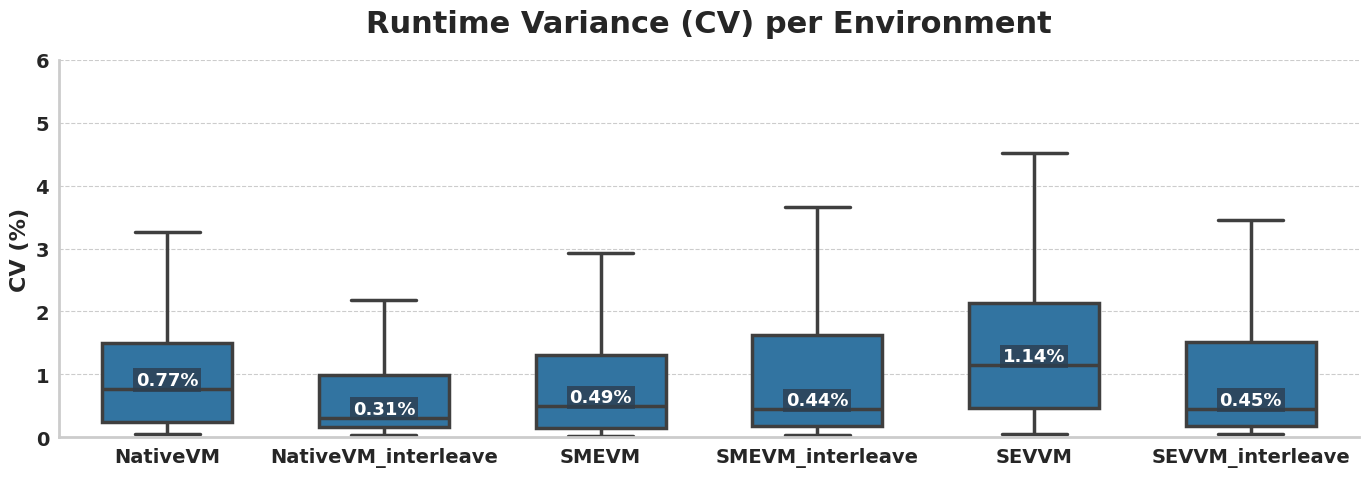

In [82]:
custom_order = ['NativeVM', 'NativeVM_interleave', 'SMEVM', 'SMEVM_interleave','SEVVM', 'SEVVM_interleave']
actual_order = [m for m in custom_order if m in df['Mode'].unique()]

plt.figure(figsize=(14, 5)) 
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})

ax = sns.boxplot(
    data=df, 
    x='Mode', 
    y='Intern_Runtime_CV', 
    order=actual_order, 
    width=0.6, 
    linewidth=2.5, 
    showfliers=False,
    zorder=2
)

plt.ylim(0, 6) 

plt.title("Runtime Variance (CV) per Environment", fontsize=22, fontweight='bold', pad=20)
plt.ylabel("CV (%)", fontsize=16, fontweight='bold')
plt.xlabel("")

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14)

for i, mode in enumerate(actual_order):
    median_val = df[df['Mode'] == mode]['Intern_Runtime_CV'].median()
    if not np.isnan(median_val) and median_val <= 6:
        plt.text(i, median_val, f'{median_val:.2f}%', 
                 ha='center', va='bottom', fontsize=13, fontweight='bold', 
                 color='white', bbox=dict(facecolor='#2c3e50', alpha=0.8, pad=2, edgecolor='none'))

for spine in ax.spines.values():
    spine.set_linewidth(2)

sns.despine()
plt.tight_layout()
plt.show()

In [83]:
pivot = df.pivot_table(
    index=['Cores', 'MB', 'Randomness'], 
    columns='Mode', 
    values=metrics
)
pivot.columns = [f'{metric}_{mode}' for metric, mode in pivot.columns]
pivot.reset_index(inplace=True)

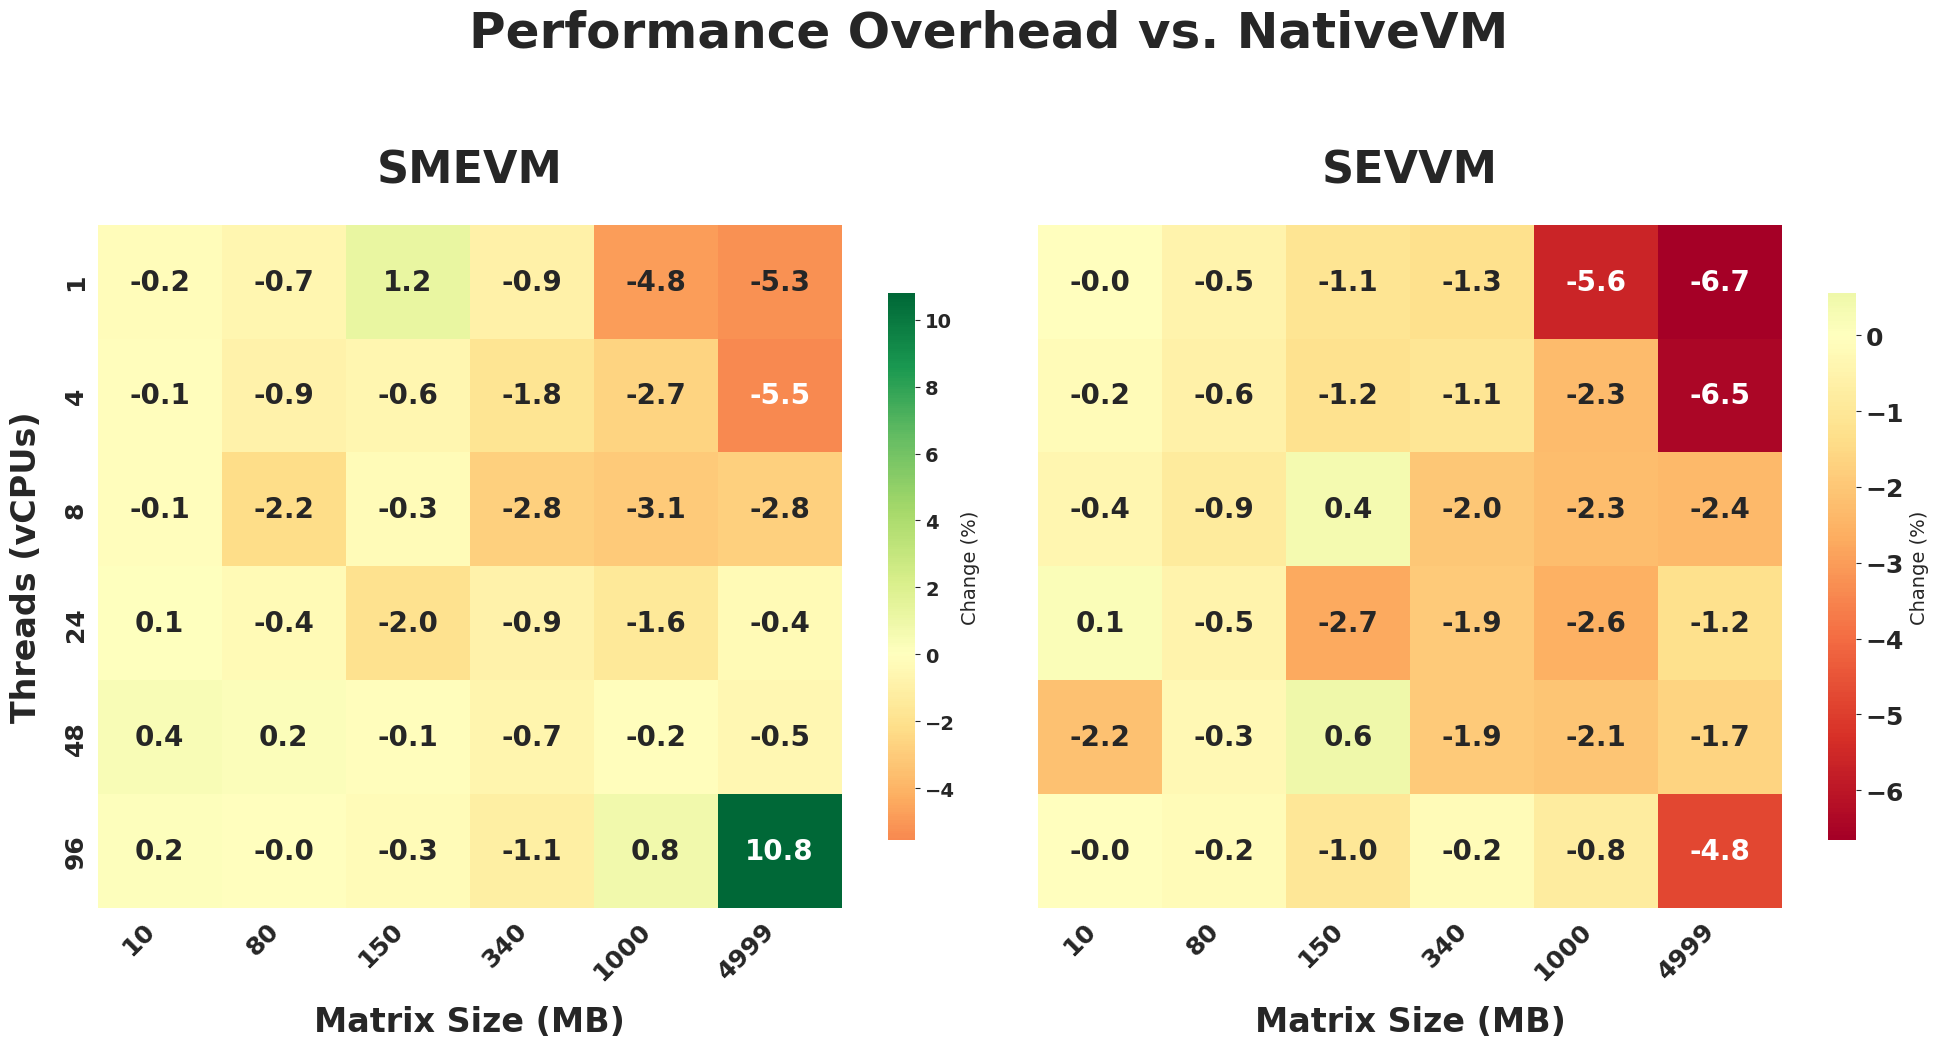

In [84]:
for mode in ['SMEVM', 'SEVVM']:
    pivot[f'Diff_{mode}'] = (pivot[f'Intern_Gflops_{mode}'] / pivot['Intern_Gflops_NativeVM'] - 1) * 100

plt.rcParams.update({'font.weight': 'bold'})

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

modes = ['SMEVM', 'SEVVM']
for i, mode in enumerate(modes):
    hm_data = pivot.pivot_table(index='Cores', columns='MB', values=f'Diff_{mode}', aggfunc='mean')
    
    sns.heatmap(
        hm_data, 
        annot=True, 
        fmt=".1f", 
        cmap="RdYlGn", 
        center=0,
        ax=axes[i],
        annot_kws={"size": 20, "weight": "bold"},
        cbar_kws={'label': 'Change (%)', 'shrink': 0.8}
    )
    
    axes[i].set_title(f"{mode}", fontsize=32, fontweight='bold', pad=30)
    
    axes[i].set_xlabel("Matrix Size (MB)", fontsize=24, fontweight='bold', labelpad=15)
    if i == 0:
        axes[i].set_ylabel("Threads (vCPUs)", fontsize=24, fontweight='bold', labelpad=15)
    else:
        axes[i].set_ylabel("")

    axes[i].tick_params(axis='both', which='major', labelsize=18)
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Performance Overhead vs. NativeVM", fontsize=36, fontweight='bold', y=1.05)

cbar = axes[1].collections[0].colorbar
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()

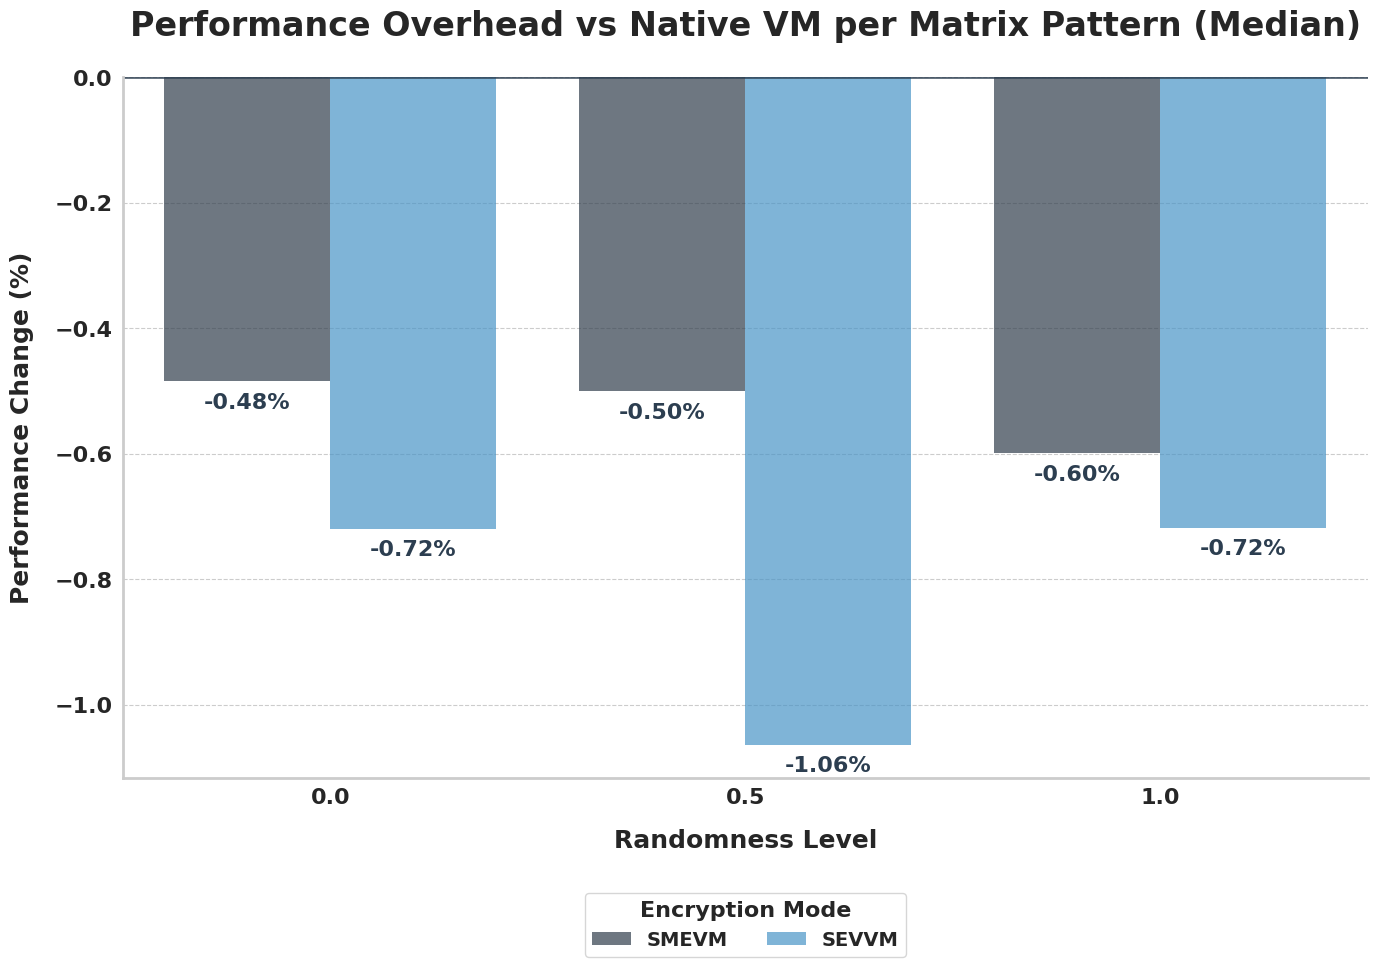

In [85]:
plot_df = pivot.melt(
    id_vars=['Randomness'], 
    value_vars=['Diff_SMEVM', 'Diff_SEVVM'], 
    var_name='Mode', 
    value_name='Overhead'
)
plot_df['Mode'] = plot_df['Mode'].str.replace('Diff_', '')

median_df = plot_df.groupby(['Randomness', 'Mode'])['Overhead'].median().reset_index()

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})

custom_palette = ["#2c3e50", "#3498db"]

ax = sns.barplot(
    data=median_df,
    x='Randomness',
    y='Overhead',
    hue='Mode',
    hue_order=['SMEVM', 'SEVVM'],
    palette=custom_palette,
    alpha=0.7,          
    edgecolor=None,     
    linewidth=0
)

plt.title("Performance Overhead vs Native VM per Matrix Pattern (Median)", fontsize=24, fontweight='bold', pad=30)
plt.ylabel("Performance Change (%)", fontsize=18, fontweight='bold', labelpad=15)
plt.xlabel("Randomness Level", fontsize=18, fontweight='bold', labelpad=15)

plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16)

plt.axhline(0, color='#2c3e50', linewidth=2, linestyle='-', alpha=0.8)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    if np.isnan(height) or height == 0: continue
    
    val_str = f'{height:+.2f}%'
    
    va = 'bottom' if height >= 0 else 'top'
    offset = 8 if height >= 0 else -8
    
    ax.annotate(val_str, 
                (p.get_x() + p.get_width()/2, height), 
                ha='center', va=va, 
                fontsize=16, fontweight='bold', 
                color='#2c3e50',
                xytext=(0, offset),
                textcoords='offset points')

for spine in ax.spines.values():
    spine.set_linewidth(2)

leg = plt.legend(title="Encryption Mode", title_fontsize='16', fontsize='14', 
                 loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                 ncol=2, frameon=True)
plt.setp(leg.get_title(), fontweight='bold')

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

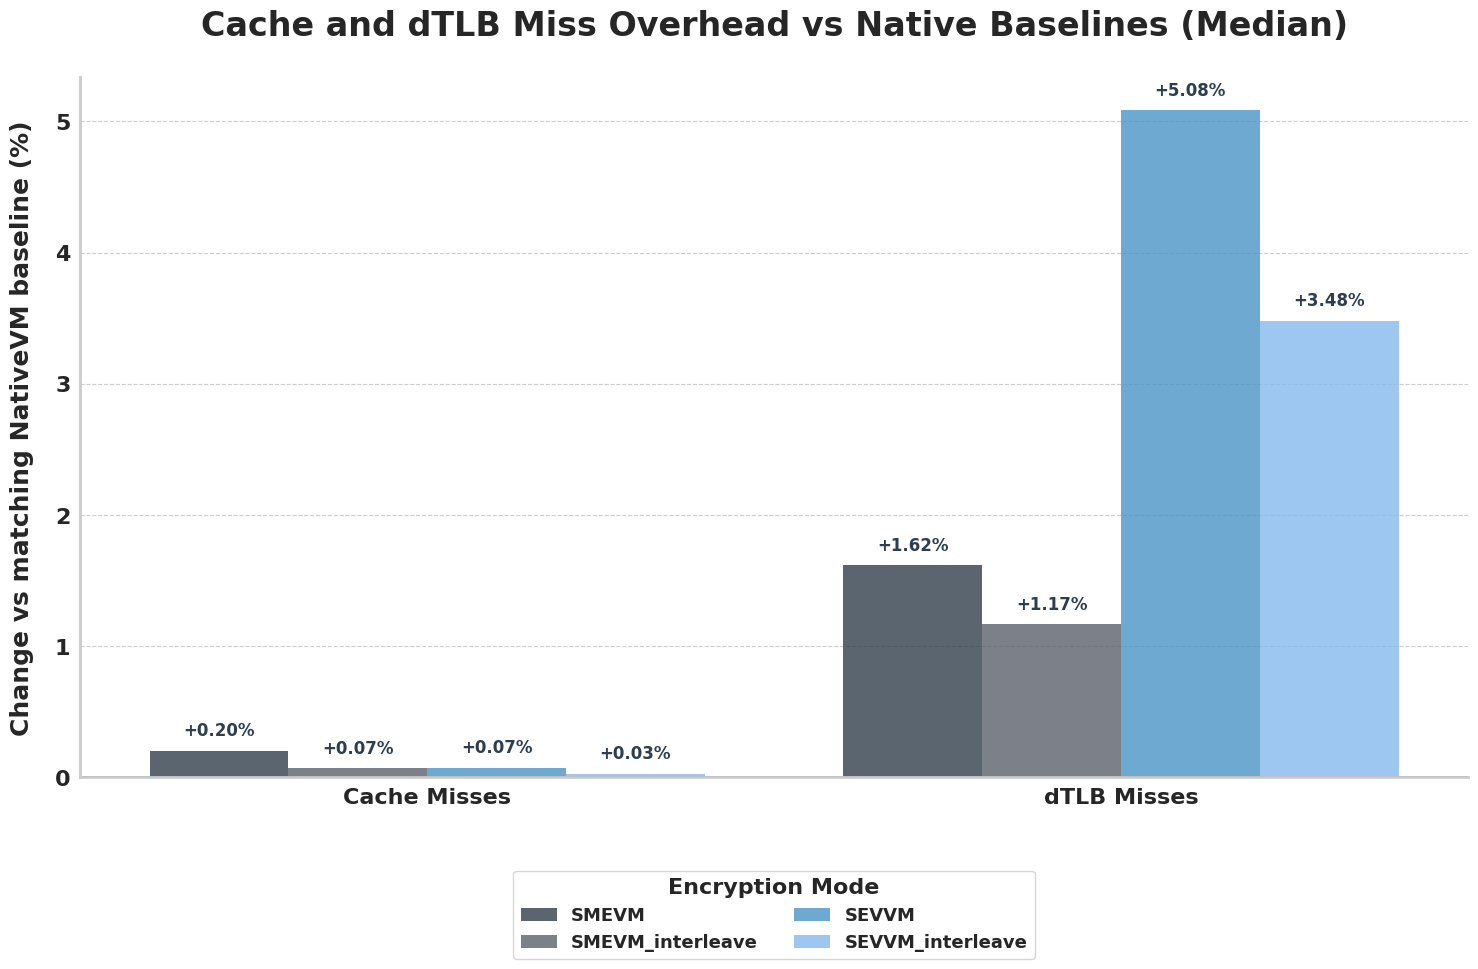

In [99]:
counter_metrics = {
    "Perf_CacheMisses": "Cache Misses",
    "Perf_dTLBLoadMisses": "dTLB Misses"
}

comparison_specs = [
    ("SMEVM", "NativeVM", "SMEVM"),
    ("SEVVM", "NativeVM", "SEVVM"),
    ("SMEVM_interleave", "NativeVM_interleave", "SMEVM_interleave"),
    ("SEVVM_interleave", "NativeVM_interleave", "SEVVM_interleave")
]

parts = []
for mode, baseline, label in comparison_specs:
    for metric_col, metric_label in counter_metrics.items():
        mode_col = f"{metric_col}_{mode}"
        base_col = f"{metric_col}_{baseline}"
        if mode_col not in pivot.columns or base_col not in pivot.columns:
            continue

        tmp = pivot[["Cores", "MB", "Randomness", mode_col, base_col]].copy()
        tmp["Mode"] = label
        tmp["Metric"] = metric_label
        tmp["Pct_Change"] = (tmp[mode_col] / tmp[base_col] - 1) * 100
        parts.append(tmp[["Cores", "MB", "Randomness", "Mode", "Metric", "Pct_Change"]])

plot_data = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(
    columns=["Cores", "MB", "Randomness", "Mode", "Metric", "Pct_Change"]
)

plot_data = plot_data[plot_data["Metric"].isin(["Cache Misses", "dTLB Misses"])].copy()
plot_data["Metric"] = pd.Categorical(
    plot_data["Metric"],
    categories=["Cache Misses", "dTLB Misses"],
    ordered=True
)

mode_order = [
    "SMEVM",
    "SMEVM_interleave",
    "SEVVM",
    "SEVVM_interleave"
]
mode_order = [m for m in mode_order if m in plot_data["Mode"].unique()]

plt.figure(figsize=(15, 10))
sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

style_palette = {
    "SMEVM": "#2c3e50",
    "SEVVM": "#3498db",
    "SMEVM_interleave": "#57606f",
    "SEVVM_interleave": "#74b9ff"
}

ax = sns.barplot(
    data=plot_data,
    x="Metric",
    y="Pct_Change",
    hue="Mode",
    hue_order=mode_order,
    estimator=np.median,
    errorbar=None,
    palette=style_palette,
    alpha=0.8,
    edgecolor=None,
    linewidth=0
)

plt.title("Cache and dTLB Miss Overhead vs Native Baselines (Median)", fontsize=24, fontweight="bold", pad=30)
plt.ylabel("Change vs matching NativeVM baseline (%)", fontsize=18, fontweight="bold", labelpad=15)
plt.xlabel("", fontsize=18, fontweight="bold", labelpad=15)

plt.xticks(fontsize=16, fontweight="bold")
plt.yticks(fontsize=16)
ax.axhline(0, color="#2c3e50", linewidth=2, linestyle="-", alpha=0.8)

for p in ax.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue

    va = "bottom" if height >= 0 else "top"
    offset = 8 if height >= 0 else -8
    ax.annotate(
        f"{height:+.2f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va=va,
        fontsize=12,
        fontweight="bold",
        color="#2c3e50",
        xytext=(0, offset),
        textcoords="offset points"
    )

for spine in ax.spines.values():
    spine.set_linewidth(2)

leg = plt.legend(
    title="Encryption Mode",
    title_fontsize="16",
    fontsize="13",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True
)
plt.setp(leg.get_title(), fontweight="bold")

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

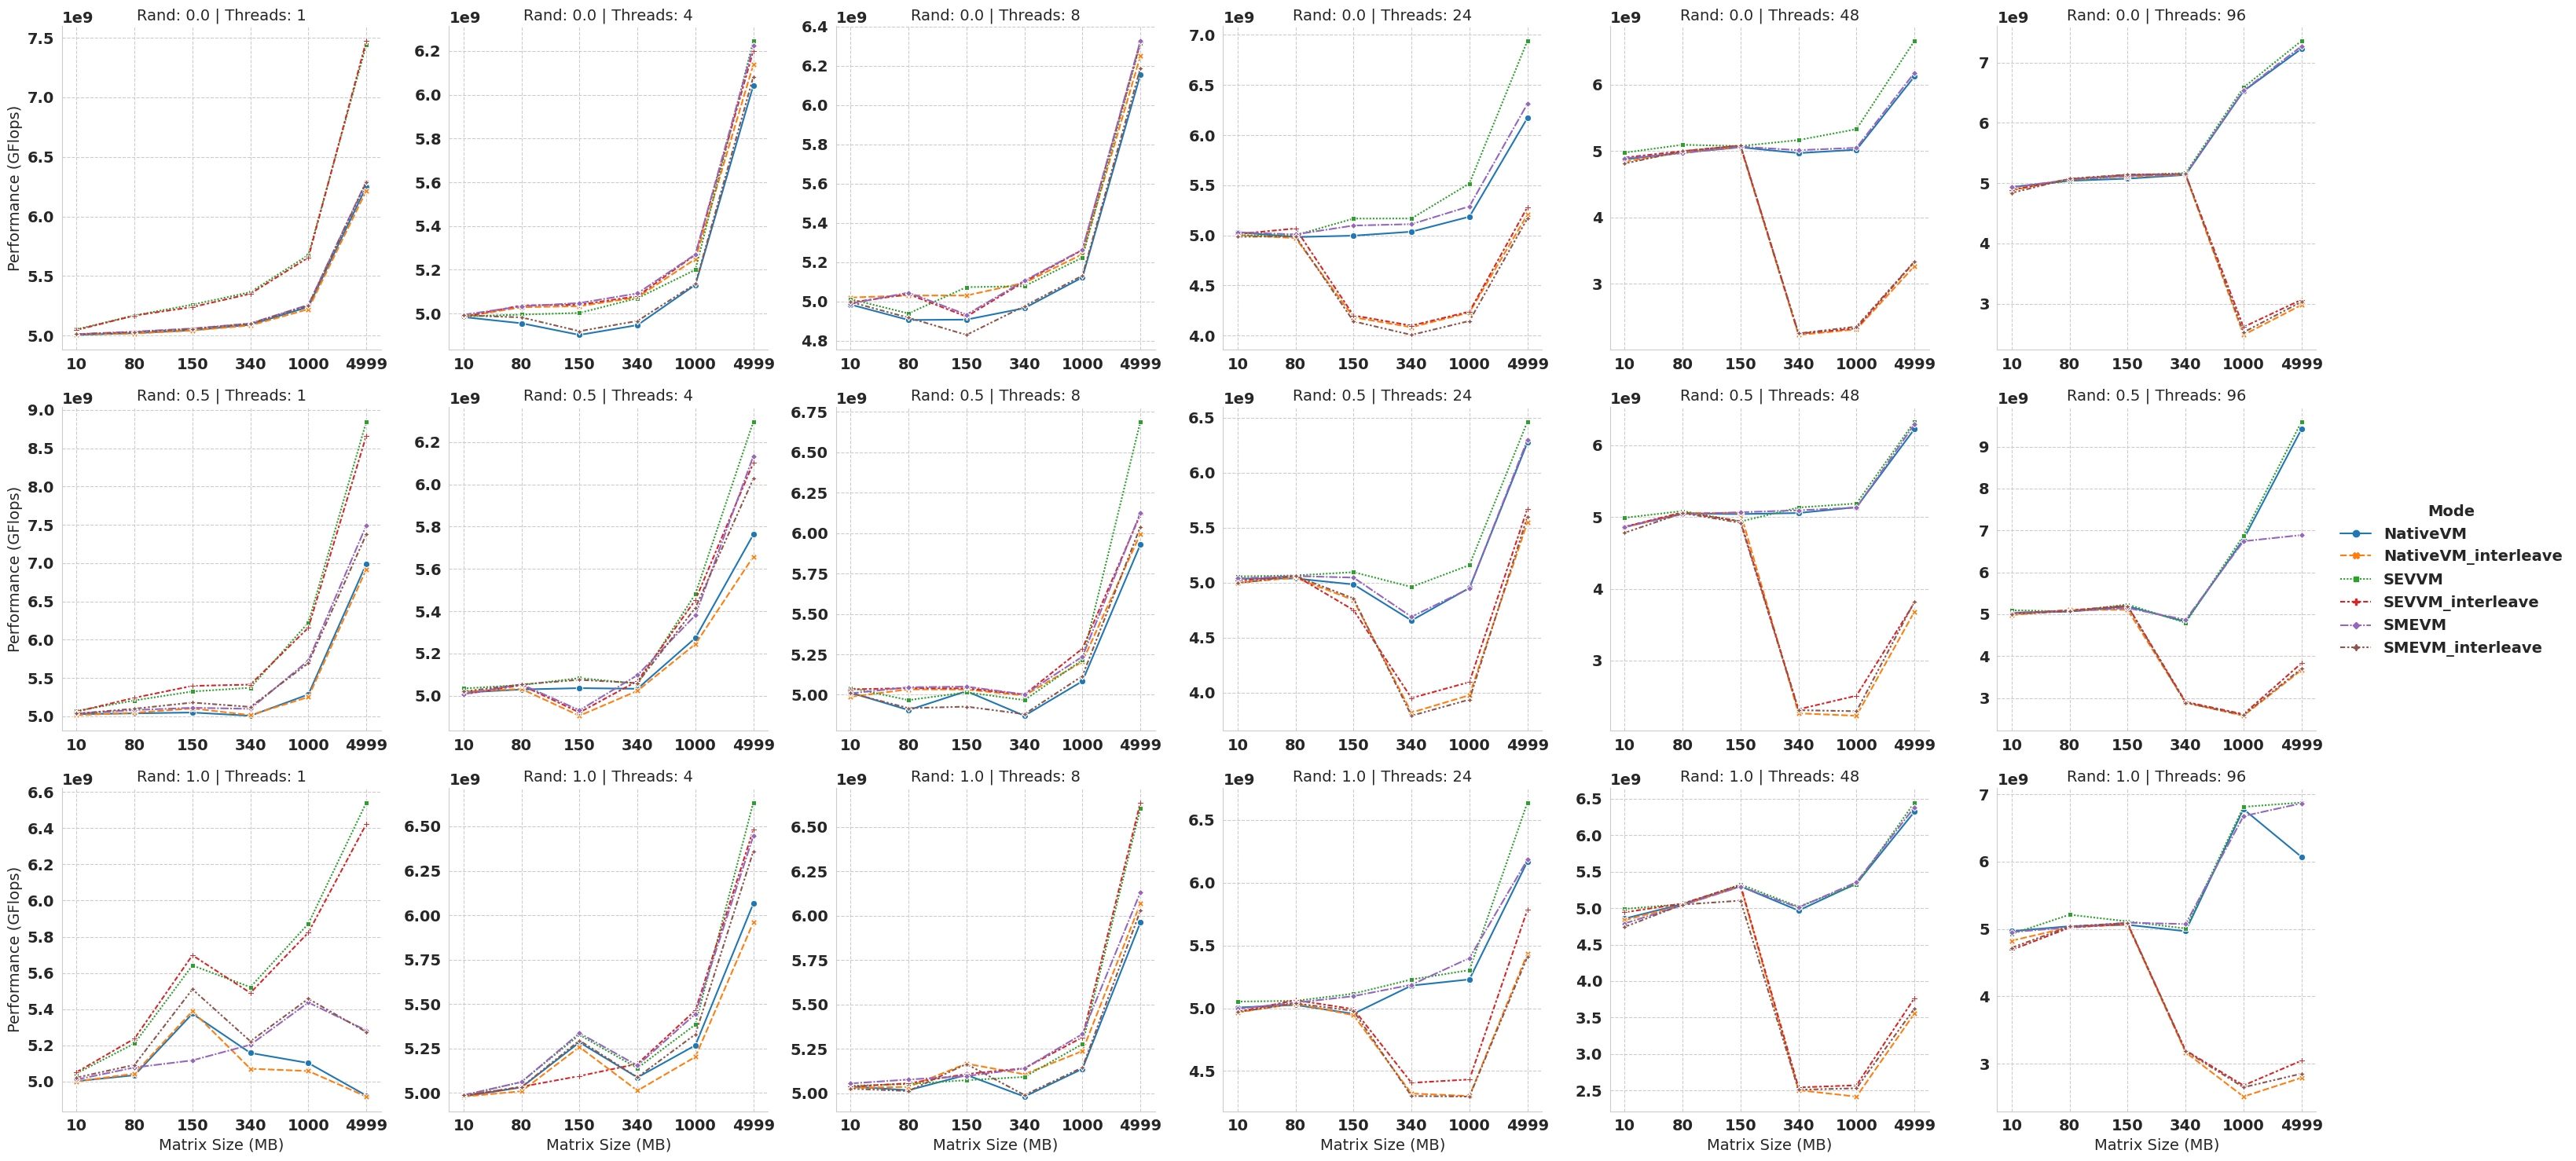

In [87]:
df_sorted = df.sort_values(['Randomness', 'MB'])
df_plot = df_sorted.assign(MB_str=df_sorted['MB'].astype(str))

g = sns.relplot(
    data=df_plot,
    x='MB_str',
    y='IOTime',
    hue='Mode',        
    style='Mode',      
    col='Cores',       
    row='Randomness', 
    kind='line',
    markers=True,
    facet_kws={'sharex': False, 'sharey': False}
)

g.set_axis_labels("Matrix Size (MB)", "Performance (GFlops)")
g.set_titles(col_template="Threads: {col_name}", row_template="Rand: {row_name}")